## Normal scaled

In [15]:
using Distributions, Random, Statistics, MultipleTesting, Empirikos, Hypatia, LinearAlgebra
using Distributions, StatsPlots, Random

Random.seed!(105)
n_values = [4, 5, 6, 8, 10, 20, 30, 40]
G = 1000
R = 300
p_signal = 0.1
β_signal = 4.0

# parametric variance model
s0_sq_true = 1.0
d0_true    = 4.0

datasets = Dict{Tuple{Int,Int}, Any}()

for n in n_values
    for r in 1:R
        rng = MersenneTwister(10_000 + 100n + r)

        is_DE = rand(rng, G) .< p_signal

        # sigma^2 from the correct parametric prior
        σ2 = rand(rng, InverseGamma(d0_true / 2, d0_true * s0_sq_true / 2), G)
        σ  = sqrt.(σ2)

        # data generation
        Y = [
            rand(rng, Normal(is_DE[i] ? β_signal * σ[i]/ sqrt(n) : 0.0, σ[i]), n)
            for i in 1:G
        ]

        datasets[(n, r)] = (
            Y = Y,
            is_DE = is_DE,
            σ = σ,
            σ2 = σ2
        )
    end
end

In [16]:
using Distributions
using Statistics

# =========================================================
# Ordinary one-sample t-test
# =========================================================

ttest_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

# NEW: store raw p-values for each replicate
ttest_pvals_store = Dict{Tuple{Int,Int}, Vector{Float64}}()


for n in n_values

    println("\n========== Running ordinary t-test for n = $n ==========")

    ν = n - 1

    power_vals = Float64[]
    fdr_vals   = Float64[]
    tp_vals    = Float64[]
    fp_vals    = Float64[]

    for r in 1:R

        Y     = datasets[(n,r)].Y
        is_DE = datasets[(n,r)].is_DE

        # 1. Compute sample mean and SD
        β_hat = [mean(Y[i]) for i in 1:G]
        s_hat = [std(Y[i], corrected=true) for i in 1:G]

        # 2. Ordinary t statistics
        t_stats = sqrt(n) .* β_hat ./ s_hat

        # 3. Two-sided RAW p-values
        tdist = TDist(n - 1)
        pvals_t = 2 .* ccdf.(Ref(tdist), abs.(t_stats))

        # =================================================
        # SAVE RAW P-VALUES
        # =================================================
        ttest_pvals_store[(n,r)] = copy(pvals_t)

        # 4. BH-adjusted p-values
        adj_p = adjust(
            pvals_t,
            BenjaminiHochberg()
        )

        # 5. Reject at FDR = 0.05
        rej_t = adj_p .<= 0.05

        # 6. Metrics
        TP = sum(rej_t .& is_DE)
        FP = sum(rej_t .& .!is_DE)

        power = TP / max(sum(is_DE), 1)
        fdr   = FP / max(sum(rej_t), 1)

        push!(tp_vals, TP)
        push!(fp_vals, FP)
        push!(power_vals, power)
        push!(fdr_vals, fdr)
    end

    mean_TP    = mean(tp_vals)
    mean_FP    = mean(fp_vals)
    mean_power = mean(power_vals)
    mean_fdr   = mean(fdr_vals)

    push!(ttest_summary["n"], n)
    push!(ttest_summary["TP"], mean_TP)
    push!(ttest_summary["FP"], mean_FP)
    push!(ttest_summary["Power"], mean_power)
    push!(ttest_summary["FDR"], mean_fdr)

    println(
        "n = $n → ",
        "Power=$(round(mean_power, digits=3)) | ",
        "FDR=$(round(mean_fdr, digits=3)) | ",
        "TP=$(round(mean_TP, digits=1)) | ",
        "FP=$(round(mean_FP, digits=1))"
    )
end


# =========================================================
# Final summary
# =========================================================

println("\n========== ORDINARY T-TEST SUMMARY ==========")

for i in eachindex(ttest_summary["n"])

    println(
        "n = $(ttest_summary["n"][i]) → ",
        "TP=$(round(ttest_summary["TP"][i], digits=3)), ",
        "FP=$(round(ttest_summary["FP"][i], digits=3)), ",
        "Power=$(round(ttest_summary["Power"][i], digits=5)), ",
        "FDR=$(round(ttest_summary["FDR"][i], digits=5))"
    )
end


========== Running ordinary t-test for n = 4 ==========
n = 4 → Power=0.004 | FDR=0.027 | TP=0.4 | FP=0.0

========== Running ordinary t-test for n = 5 ==========
n = 5 → Power=0.02 | FDR=0.045 | TP=2.0 | FP=0.2

========== Running ordinary t-test for n = 6 ==========
n = 6 → Power=0.085 | FDR=0.04 | TP=8.6 | FP=0.5

========== Running ordinary t-test for n = 8 ==========
n = 8 → Power=0.339 | FDR=0.046 | TP=34.4 | FP=1.8

========== Running ordinary t-test for n = 10 ==========
n = 10 → Power=0.51 | FDR=0.045 | TP=51.3 | FP=2.5

========== Running ordinary t-test for n = 20 ==========
n = 20 → Power=0.749 | FDR=0.044 | TP=75.1 | FP=3.5

========== Running ordinary t-test for n = 30 ==========
n = 30 → Power=0.802 | FDR=0.046 | TP=80.0 | FP=3.9

========== Running ordinary t-test for n = 40 ==========
n = 40 → Power=0.827 | FDR=0.045 | TP=82.5 | FP=3.9

========== ORDINARY T-TEST SUMMARY ==========
n = 4 → TP=0.393, FP=0.05, Power=0.00403, FDR=0.02706
n = 5 → TP=2.027, FP=0.2, Power=0

In [5]:
using FastGaussQuadrature
using Distributions
using StatsFuns: logsumexp
using Optim
using MultipleTesting
using Statistics, Random, LinearAlgebra
using ApproxFun, SpecialFunctions

# =========================================================
# 1. Exact MAD-about-mean likelihood
# =========================================================

struct MADDistribution{T<:Real,S<:Integer} <: ContinuousUnivariateDistribution
    σ::T
    n::S
end

import Distributions: pdf, logpdf, insupport, minimum, maximum

function G_recursive(max_r::Int; a=0.0, b=100)
    d = Interval(a, b)
    G = Vector{Fun}(undef, max_r+1)
    G[1] = Fun(x -> 1.0, d)
    for r in 1:max_r
        integrand = Fun(x -> exp(-(x^2)/(2r*(r+1))), d) * G[r]
        G[r+1] = cumsum(integrand)
    end
    return G
end

const _Gcache = Dict{Int,Vector{Fun}}()
_getG(n) = get!(_Gcache, n) do
    G_recursive(n)
end

function _pdf_sigma1(n::Int, m::Real)
    m < 0 && return zero(float(m))
    z   = n * m / 2
    cst = n^(3/2) / (2^((n+1)/2) * π^((n-1)/2))
    G   = _getG(n)
    s   = 0.0
    @inbounds for k in 1:(n-1)
        s += binomial(n, k) * exp(-(m^2 * n^3) / (8k*(n-k))) * G[k](z) * G[n-k](z)
    end
    return cst * s
end

insupport(::MADDistribution, x::Real) = x ≥ 0
minimum(::MADDistribution) = 0.0
maximum(::MADDistribution) = Inf

pdf(d::MADDistribution, m::Real) =
    m < 0 ? 0.0 : (1 / d.σ) * _pdf_sigma1(d.n, m / d.σ)

function logpdf(d::MADDistribution, m::Real)
    m < 0 && return -Inf
    σ, n = d.σ, d.n
    z    = n * m / (2σ)
    logC = (3/2)*log(n) - ((n+1)/2)*log(2) - ((n-1)/2)*log(π)
    G    = _getG(n)

    logs = Float64[]
    @inbounds for k in 1:(n-1)
        val1 = G[k](z)
        val2 = G[n-k](z)
        if val1 > 0 && val2 > 0
            push!(logs,
                log(binomial(n, k)) -
                (m^2 * n^3) / (8σ^2 * k*(n-k)) +
                log(val1) + log(val2)
            )
        end
    end

    return -log(σ) + logC + (isempty(logs) ? -Inf : logsumexp(logs))
end


logpdf (generic function with 89 methods)

In [6]:
using FastGaussQuadrature
using Distributions
using Statistics
using MultipleTesting

# =========================================================
# Precompute quadrature for the exact MAD-normalized null
#
# Integral:
#
# p(t) = ∫ 2 Φbar(|t| c_n w) f_D(w | sigma=1,n) dw
#
# Transform:
#     w = u / (1-u),   u ∈ (0,1)
# =========================================================

function build_mad_null_quadrature(
    n::Int;
    K::Int = 400
)

    # Gauss-Legendre on [-1,1]
    x, qweights = gausslegendre(K)

    # Map to (0,1)
    u = (x .+ 1) ./ 2
    qweights ./= 2

    # Transform (0,1) -> (0,Inf)
    w_nodes = u ./ (1 .- u)

    jac = 1 ./ (1 .- u).^2

    # Exact MAD density evaluated ONLY ONCE
    mad_density = [
        pdf(
            MADDistribution(1.0, n),
            w
        )
        for w in w_nodes
    ]

    # Complete integration weights
    weights =
        qweights .* jac .* mad_density

    # Optional normalization to remove tiny numerical integration error
    weights ./= sum(weights)

    c_n =
        sqrt(pi / 2) *
        sqrt(n / (n - 1))

    return (
        w = w_nodes,
        weights = weights,
        c_n = c_n
    )
end

mad_quad_store =
    Dict{Int, Any}()

for n in n_values

    println(
        "Precomputing MAD null quadrature for n = $n"
    )

    @time mad_quad_store[n] =
        build_mad_null_quadrature(
            n;
            K = 400
        )
end

function mad_H_pvalue_fast(
    h_obs::Real,
    quad
)
    x = abs(h_obs)

    tails =
        2 .* ccdf.(
            Normal(),
            x .* quad.w
        )

    p = dot(
        quad.weights,
        tails
    )

    return clamp(p, 0.0, 1.0)
end

Precomputing MAD null quadrature for n = 4
  2.658664 seconds (30.60 M allocations: 1.549 GiB, 6.08% gc time, 99.52% compilation time)
Precomputing MAD null quadrature for n = 5
  0.005492 seconds (13.42 k allocations: 901.188 KiB)
Precomputing MAD null quadrature for n = 6
  0.009709 seconds (16.33 k allocations: 990.672 KiB)
Precomputing MAD null quadrature for n = 8
  0.008560 seconds (22.11 k allocations: 1.271 MiB)
Precomputing MAD null quadrature for n = 10
  0.009420 seconds (27.86 k allocations: 1.615 MiB)
Precomputing MAD null quadrature for n = 20
  0.015357 seconds (62.64 k allocations: 3.528 MiB)
Precomputing MAD null quadrature for n = 30
  0.020433 seconds (95.34 k allocations: 5.621 MiB)
Precomputing MAD null quadrature for n = 40
  0.027528 seconds (128.82 k allocations: 7.679 MiB)


mad_H_pvalue_fast (generic function with 1 method)

In [17]:
mad_test_summary = Dict(
    "n" => Int[],
    "TP" => Float64[],
    "FP" => Float64[],
    "Power" => Float64[],
    "FDR" => Float64[]
)

# NEW: store raw p-values for ranking analysis
mad_test_pvals_store =
    Dict{Tuple{Int,Int}, Vector{Float64}}()


for n in n_values

    println(
        "\n========== Running MAD-normalized test for n = $n =========="
    )

    quad = mad_quad_store[n]

    power_vals = Float64[]
    fdr_vals   = Float64[]
    tp_vals    = Float64[]
    fp_vals    = Float64[]

    for r in 1:R

        Y =
            datasets[(n,r)].Y

        is_DE =
            datasets[(n,r)].is_DE

        # ---------------------------------------------
        # 1. Sample means
        # ---------------------------------------------

        β_hat = [
            mean(Y[i])
            for i in 1:G
        ]

        # ---------------------------------------------
        # 2. MAD about sample mean
        # ---------------------------------------------

        mad_obs = [
            mean(
                abs.(
                    Y[i] .- β_hat[i]
                )
            )
            for i in 1:G
        ]

        h_mad =
            sqrt(n) .* β_hat ./ mad_obs

        # ---------------------------------------------
        # 3. Exact numerical raw p-values
        # ---------------------------------------------

        pvals_mad = [
            mad_H_pvalue_fast(h, quad)
            for h in h_mad
        ]

        # ---------------------------------------------
        # NEW: save raw p-values
        # ---------------------------------------------

        mad_test_pvals_store[(n,r)] =
            copy(pvals_mad)

        # ---------------------------------------------
        # 4. BH adjustment
        # ---------------------------------------------

        adj_p =
            adjust(
                pvals_mad,
                BenjaminiHochberg()
            )

        rej_mad =
            adj_p .<= 0.05

        # ---------------------------------------------
        # 5. Performance
        # ---------------------------------------------

        TP =
            sum(rej_mad .& is_DE)

        FP =
            sum(rej_mad .& .!is_DE)

        power =
            TP / max(sum(is_DE), 1)

        fdp =
            FP / max(sum(rej_mad), 1)

        push!(tp_vals, TP)
        push!(fp_vals, FP)
        push!(power_vals, power)
        push!(fdr_vals, fdp)
    end

    # ---------------------------------------------
    # Average across replicates
    # ---------------------------------------------

    mean_TP =
        mean(tp_vals)

    mean_FP =
        mean(fp_vals)

    mean_power =
        mean(power_vals)

    mean_fdr =
        mean(fdr_vals)

    push!(mad_test_summary["n"], n)
    push!(mad_test_summary["TP"], mean_TP)
    push!(mad_test_summary["FP"], mean_FP)
    push!(mad_test_summary["Power"], mean_power)
    push!(mad_test_summary["FDR"], mean_fdr)

    println(
        "n = $n → ",
        "Power=$(round(mean_power,digits=3)) | ",
        "FDR=$(round(mean_fdr,digits=3)) | ",
        "TP=$(round(mean_TP,digits=1)) | ",
        "FP=$(round(mean_FP,digits=1))"
    )
end


println(
    "\n========== MAD NORMALIZED TEST SUMMARY =========="
)

for i in eachindex(mad_test_summary["n"])

    println(
        "n = $(mad_test_summary["n"][i]) → ",
        "TP=$(round(mad_test_summary["TP"][i],digits=3)), ",
        "FP=$(round(mad_test_summary["FP"][i],digits=3)), ",
        "Power=$(round(mad_test_summary["Power"][i],digits=5)), ",
        "FDR=$(round(mad_test_summary["FDR"][i],digits=5))"
    )
end


========== Running MAD-normalized test for n = 4 ==========
n = 4 → Power=0.005 | FDR=0.031 | TP=0.5 | FP=0.1

========== Running MAD-normalized test for n = 5 ==========
n = 5 → Power=0.021 | FDR=0.036 | TP=2.1 | FP=0.2

========== Running MAD-normalized test for n = 6 ==========
n = 6 → Power=0.078 | FDR=0.04 | TP=7.9 | FP=0.5

========== Running MAD-normalized test for n = 8 ==========
n = 8 → Power=0.315 | FDR=0.046 | TP=32.0 | FP=1.6

========== Running MAD-normalized test for n = 10 ==========
n = 10 → Power=0.481 | FDR=0.044 | TP=48.4 | FP=2.3

========== Running MAD-normalized test for n = 20 ==========
n = 20 → Power=0.731 | FDR=0.044 | TP=73.3 | FP=3.5

========== Running MAD-normalized test for n = 30 ==========
n = 30 → Power=0.791 | FDR=0.046 | TP=79.0 | FP=3.8

========== Running MAD-normalized test for n = 40 ==========
n = 40 → Power=0.82 | FDR=0.045 | TP=81.8 | FP=3.9

========== MAD NORMALIZED TEST SUMMARY ==========
n = 4 → TP=0.47, FP=0.063, Power=0.00478, FDR=0.03

In [18]:
function bh_raw_cutoff(pvals; q=0.05)

    m = length(pvals)
    ps = sort(pvals)

    ok = findall(
        ps .<= (1:m) .* q ./ m
    )

    return isempty(ok) ? 0.0 : ps[maximum(ok)]
end

bh_raw_cutoff (generic function with 1 method)

In [19]:
for n in n_values

    cut_t   = Float64[]
    cut_mad = Float64[]

    for r in 1:R

        p_t =
            ttest_pvals_store[(n,r)]

        p_mad =
            mad_test_pvals_store[(n,r)]

        push!(
            cut_t,
            bh_raw_cutoff(p_t)
        )

        push!(
            cut_mad,
            bh_raw_cutoff(p_mad)
        )
    end

    println(
        "n = $n | ",
        "mean BH cutoff t = ",
        mean(cut_t),
        " | MAD = ",
        mean(cut_mad)
    )
end

n = 4 | mean BH cutoff t = 1.4186770508001599e-5 | MAD = 1.9605034499576687e-5
n = 5 | mean BH cutoff t = 9.14356328637979e-5 | MAD = 9.24420129227425e-5
n = 6 | mean BH cutoff t = 0.0004134303989165568 | MAD = 0.0003751045716005673
n = 8 | mean BH cutoff t = 0.00172139238790707 | MAD = 0.0015941288599539357
n = 10 | mean BH cutoff t = 0.0025681573797028644 | MAD = 0.0024231693969885633
n = 20 | mean BH cutoff t = 0.003699446304842328 | MAD = 0.003638092871471273
n = 30 | mean BH cutoff t = 0.003915486584734751 | MAD = 0.0038875194489972334
n = 40 | mean BH cutoff t = 0.00400884833959138 | MAD = 0.004012148632144669


In [1]:
using JLD2

@load "method_pvalues(6.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps limma_pvals_store epb_pvals_store mad_pvals_store mad_param_pvals_store is_DE_store

12-element Vector{Symbol}:
 :simulation_params
 :limma_summary
 :epb_summary
 :mad_summary
 :mad_param_gl_summary
 :mad_param_gl_prior_summary
 :mad_param_gl_prior_reps
 :limma_pvals_store
 :epb_pvals_store
 :mad_pvals_store
 :mad_param_pvals_store
 :is_DE_store

In [8]:
using JLD2

@load "method_pvalues(6.1).jld2" simulation_params limma_summary epb_summary mad_summary mad_param_gl_summary mad_param_gl_prior_summary mad_param_gl_prior_reps limma_pvals_store epb_pvals_store mad_pvals_store mad_param_pvals_store is_DE_store

12-element Vector{Symbol}:
 :simulation_params
 :limma_summary
 :epb_summary
 :mad_summary
 :mad_param_gl_summary
 :mad_param_gl_prior_summary
 :mad_param_gl_prior_reps
 :limma_pvals_store
 :epb_pvals_store
 :mad_pvals_store
 :mad_param_pvals_store
 :is_DE_store

In [9]:
using JLD2
using Statistics
using DataFrames
using Plots

# ---------------------------------------------------------
# 1. Define methods
# ---------------------------------------------------------

method_order = [
    "t-test",
    "MAD test",
    "LIMMA",
    "SD (NP)",
    "MAD (NP)",
    "MAD (Param)"
]

methods = Dict(
    "t-test"      => ttest_pvals_store,
    "MAD test"    => mad_test_pvals_store,
    "LIMMA"       => limma_pvals_store,
    "SD (NP)"     => epb_pvals_store,
    "MAD (NP)"    => mad_pvals_store,
    "MAD (Param)" => mad_param_pvals_store
)

performance_summaries = Dict(
    "t-test"      => ttest_summary,
    "MAD test"    => mad_test_summary,
    "LIMMA"       => limma_summary,
    "SD (NP)"     => epb_summary,
    "MAD (NP)"    => mad_summary,
    "MAD (Param)" => mad_param_gl_summary
)

Dict{String, Dict{String, Vector}} with 6 entries:
  "MAD (NP)"    => Dict("TP"=>[34.64, 44.32, 50.14, 59.13, 65.8763, 76.17, 79.2…
  "MAD test"    => Dict("TP"=>[0.61, 2.16, 8.02, 31.96, 48.95, 72.43, 78.01, 81…
  "LIMMA"       => Dict("TP"=>[34.66, 43.84, 50.55, 59.99, 66.89, 76.75, 80.05,…
  "MAD (Param)" => Dict("TP"=>[34.16, 43.38, 49.86, 58.79, 65.51, 76.02, 79.44,…
  "SD (NP)"     => Dict("TP"=>[35.5556, 45.01, 50.9899, 60.48, 67.14, 77.03, 80…
  "t-test"      => Dict("TP"=>[0.57, 2.15, 8.87, 34.0, 51.77, 74.22, 79.07, 82.…

In [10]:
function hits_at_k(pvals, is_DE; k=100)
    k_use = min(k, length(pvals))

    top_idx = partialsortperm(
        pvals,
        1:k_use
    )

    return sum(is_DE[top_idx])
end


function average_precision(pvals, is_DE)

    ord = sortperm(pvals)

    truth_ranked = is_DE[ord]
    n_de = sum(truth_ranked)

    if n_de == 0
        return NaN
    end

    cum_tp = cumsum(truth_ranked)

    precision_at_k =
        cum_tp ./ collect(1:length(pvals))

    ap =
        sum(precision_at_k[truth_ranked]) / n_de

    return ap
end

average_precision (generic function with 1 method)

In [11]:
function build_ranking_summary(methods, is_DE_store; k=100)

    common_keys = reduce(
        intersect,
        [Set(keys(store)) for store in values(methods)]
    )

    common_keys = intersect(
        common_keys,
        Set(keys(is_DE_store))
    )

    println("Number of common (n, rep) pairs = ", length(common_keys))

    ranking_df = DataFrame(
        n = Int[],
        rep = Int[],
        method = String[],
        hits100 = Int[],
        AP = Float64[]
    )

    for key in sort(collect(common_keys))

        n, r = key
        is_DE = is_DE_store[key]

        for (method, store) in methods

            pvals = store[key]

            push!(
                ranking_df,
                (
                    n = n,
                    rep = r,
                    method = method,
                    hits100 = hits_at_k(pvals, is_DE; k=k),
                    AP = average_precision(pvals, is_DE)
                )
            )
        end
    end

    ranking_summary = DataFrames.combine(
        DataFrames.groupby(ranking_df, [:n, :method]),

        :hits100 => mean => :mean_hits100,
        :hits100 => std  => :sd_hits100,

        :AP => mean => :mean_AP,
        :AP => std  => :sd_AP,

        DataFrames.nrow => :R
    )

    ranking_summary.se_hits100 =
        ranking_summary.sd_hits100 ./ sqrt.(ranking_summary.R)

    ranking_summary.se_AP =
        ranking_summary.sd_AP ./ sqrt.(ranking_summary.R)

    sort!(ranking_summary, [:method, :n])

    return ranking_df, ranking_summary
end

build_ranking_summary (generic function with 1 method)

In [12]:
function summary_to_df(summary, method)

    return DataFrame(
        n = summary["n"],
        method = fill(method, length(summary["n"])),
        Power = summary["Power"],
        FDR = summary["FDR"]
    )
end


function build_performance_df(performance_summaries, method_order)

    dfs = [
        summary_to_df(performance_summaries[method], method)
        for method in method_order
    ]

    performance_df = vcat(dfs...)

    sort!(performance_df, [:method, :n])

    return performance_df
end

build_performance_df (generic function with 1 method)

In [13]:
ranking_df, ranking_summary =
    build_ranking_summary(
        methods,
        is_DE_store;
        k = 100
    )

performance_df =
    build_performance_df(
        performance_summaries,
        method_order
    )

plot_df = DataFrames.leftjoin(
    performance_df,
    ranking_summary[:, [:n, :method, :mean_hits100, :mean_AP]],
    on = [:n, :method]
)

sort!(plot_df, [:method, :n])

Number of common (n, rep) pairs = 793


Row,n,method,Power,FDR,mean_hits100,mean_AP
,Int64,String,Float64,Float64,Float64?,Float64?
1,4,LIMMA,0.346492,0.0416939,80.5758,0.886079
2,5,LIMMA,0.43545,0.0487064,82.31,0.89703
3,6,LIMMA,0.504595,0.0521226,82.8788,0.905842
4,8,LIMMA,0.598256,0.0434482,84.82,0.928636
5,10,LIMMA,0.66482,0.0441094,85.9072,0.93644
6,20,LIMMA,0.765415,0.0446775,87.82,0.954433
7,30,LIMMA,0.811623,0.0449984,88.3878,0.963124
8,40,LIMMA,0.830209,0.0459352,89.16,0.964052
9,4,MAD (NP),0.345971,0.0428251,80.4545,0.883285


In [14]:
println("\nFull plot_df:")

show(
    stdout,
    MIME("text/plain"),
    plot_df;
    allrows = true,
    allcols = true
)

println("\n")


Full plot_df:
48×6 DataFrame
 Row │ n      method       Power       FDR        mean_hits100  mean_AP  
     │ Int64  String       Float64     Float64    Float64?      Float64? 
─────┼───────────────────────────────────────────────────────────────────
   1 │     4  LIMMA        0.346492    0.0416939       80.5758  0.886079
   2 │     5  LIMMA        0.43545     0.0487064       82.31    0.89703
   3 │     6  LIMMA        0.504595    0.0521226       82.8788  0.905842
   4 │     8  LIMMA        0.598256    0.0434482       84.82    0.928636
   5 │    10  LIMMA        0.66482     0.0441094       85.9072  0.93644
   6 │    20  LIMMA        0.765415    0.0446775       87.82    0.954433
   7 │    30  LIMMA        0.811623    0.0449984       88.3878  0.963124
   8 │    40  LIMMA        0.830209    0.0459352       89.16    0.964052
   9 │     4  MAD (NP)     0.345971    0.0428251       80.4545  0.883285
  10 │     5  MAD (NP)     0.440269    0.0514325       81.91    0.89326
  11 │     6  MAD (NP

In [22]:
function plot_metric(
    df,
    method_order,
    ycol;
    ylabel = "",
    title = "",
    legend = false,
    ylim = nothing,
    hline_value = nothing
)

    p = plot(
        xlabel = "Sample size n",
        ylabel = ylabel,
        title = title,
        legend = legend
    )

    if ylim !== nothing
        plot!(p, ylim = ylim)
    end

    for method in method_order

        tmp = filter(
            row -> row.method == method,
            df
        )

        sort!(tmp, :n)

        plot!(
            p,
            tmp.n,
            tmp[!, ycol],
            marker = :circle,
            linewidth = 2,
            label = method
        )
    end

    if hline_value !== nothing
        hline!(
            p,
            [hline_value],
            linestyle = :dash,
            label = ""
        )
    end

    return p
end

plot_metric (generic function with 1 method)

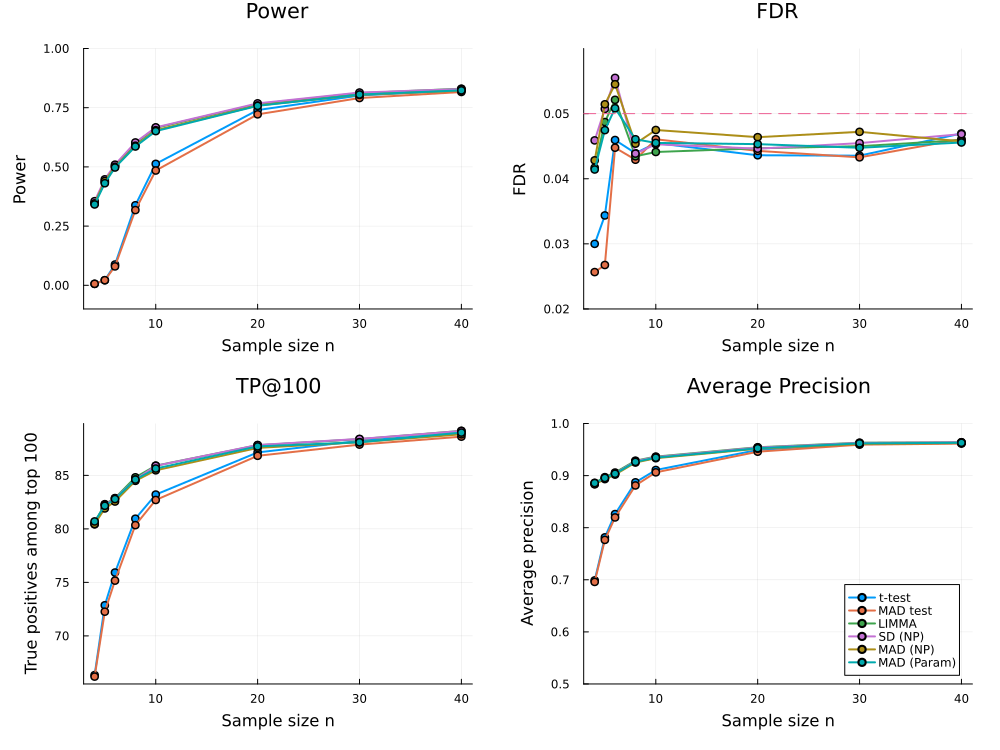

In [32]:
p_power = plot_metric(
    plot_df,
    method_order,
    :Power;
    ylabel = "Power",
    title = "Power",
    ylim = (-0.1, 1)
)

p_fdr = plot_metric(
    plot_df,
    method_order,
    :FDR;
    ylabel = "FDR",
    title = "FDR",
    hline_value = 0.05,
    ylim = (0.02, 0.06)
)

p_hits = plot_metric(
    plot_df,
    method_order,
    :mean_hits100;
    ylabel = "True positives among top 100",
    title = "TP@100"
)

p_ap = plot_metric(
    plot_df,
    method_order,
    :mean_AP;
    ylabel = "Average precision",
    title = "Average Precision",
    ylim = (0.5, 1),
    legend = :bottomright
)

p_all = plot(
    p_power,
    p_fdr,
    p_hits,
    p_ap,
    layout = (2, 2),
    size = (1000, 750),
    margin = 5Plots.mm
)

display(p_all)

In [34]:
method_order = [
    "t-test",
    "MAD test",
    "LIMMA",
    "MAD (Param)"
]

methods = Dict(
    "t-test"      => ttest_pvals_store,
    "MAD test"    => mad_test_pvals_store,
    "LIMMA"       => limma_pvals_store,
    "MAD (Param)" => mad_param_pvals_store
)

performance_summaries = Dict(
    "t-test"      => ttest_summary,
    "MAD test"    => mad_test_summary,
    "LIMMA"       => limma_summary,
    "MAD (Param)" => mad_param_gl_summary
)

Dict{String, Dict{String, Vector}} with 4 entries:
  "MAD test"    => Dict("TP"=>[0.61, 2.16, 8.02, 31.96, 48.95, 72.43, 78.01, 81…
  "LIMMA"       => Dict("TP"=>[34.66, 43.84, 50.55, 59.99, 66.89, 76.75, 80.05,…
  "MAD (Param)" => Dict("TP"=>[34.16, 43.38, 49.86, 58.79, 65.51, 76.02, 79.44,…
  "t-test"      => Dict("TP"=>[0.57, 2.15, 8.87, 34.0, 51.77, 74.22, 79.07, 82.…

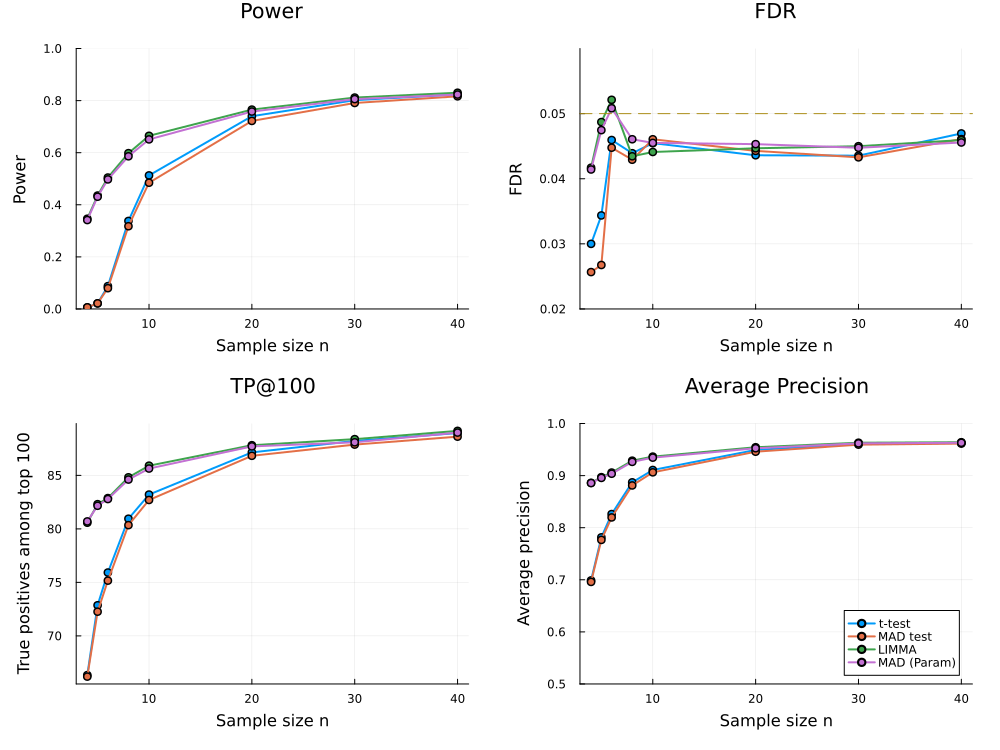

In [36]:
p_power = plot_metric(
    plot_df,
    method_order,
    :Power;
    ylabel = "Power",
    title = "Power",
    ylim = (0, 1)
)

p_fdr = plot_metric(
    plot_df,
    method_order,
    :FDR;
    ylabel = "FDR",
    title = "FDR",
    hline_value = 0.05,
    ylim = (0.02, 0.06)
)

p_hits = plot_metric(
    plot_df,
    method_order,
    :mean_hits100;
    ylabel = "True positives among top 100",
    title = "TP@100"
)

p_ap = plot_metric(
    plot_df,
    method_order,
    :mean_AP;
    ylabel = "Average precision",
    title = "Average Precision",
    ylim = (0.5, 1),
    legend = :bottomright,
)

p_all = plot(
    p_power,
    p_fdr,
    p_hits,
    p_ap,
    layout = (2, 2),
    size = (1000, 750),
    margin = 5Plots.mm
)

display(p_all)